In [1]:
import torch
import torch.nn as nn

class ADNClassifier(nn.Module):
    def __init__(self, input_size, vocab_size, embed_size, hidden_size):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_size)
        self.feats = nn.Sequential(
            nn.Conv1d(input_size, hidden_size, kernel_size=1, padding=1),
            nn.ReLU(),
            nn.AdaptiveAvgPool1d(1),
        )
        self.classifier = nn.Sequential(
            nn.Linear(hidden_size, hidden_size),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(hidden_size, 1),
        )

    def forward(self, x):  # x: (batch_size, seq_length)
        x = self.embedding(x)  # x: (batch_size, seq_length, embed_size)

        #x = x.transpose(1, 2)   # x: (batch_size, embed_size, seq_length)

        x = self.feats(x)       # x: (batch_size, seq_length, 1)
        x = x.squeeze(-1)       # x: (batch_size, hidden_size)
        x = self.classifier(x)  # x: (batch_size, 1)
        return x.squeeze(-1)    # x: (batch_size)

    def fit(self, X, y, epochs=10, batch_size=32, learning_rate=0.001, validation_data=None):
        optimizer = torch.optim.Adam(self.parameters(), lr=learning_rate)
        criterion = nn.BCEWithLogitsLoss()
        dataset = torch.utils.data.TensorDataset(X, y)
        dataloader = torch.utils.data.DataLoader(dataset, batch_size=batch_size, shuffle=True)

        history = {'loss': [], 'val_accuracy': [], 'train_accuracy': []}

        for epoch in range(epochs):
            loss_total = 0.0
            self.train()
            for batch_X, batch_y in dataloader:
                optimizer.zero_grad()
                outputs = self.forward(batch_X)
                loss = criterion(outputs, batch_y)
                loss.backward()
                optimizer.step()
                loss_total += loss.item() * batch_X.size(0)
            loss_mean = loss_total / len(dataloader.dataset)

            train_acc = self.evaluate(X, y)
            val_acc = self.evaluate(validation_data[0], validation_data[1]) if validation_data else 0.0
            history['loss'].append(loss_mean)
            history['val_accuracy'].append(val_acc)
            history['train_accuracy'].append(train_acc)

            print(f'Epoch {epoch+1}/{epochs}, Loss: {loss_mean:.4f}')
            print(f'Training Accuracy: {train_acc * 100:.2f}%')

            if validation_data:
                print(f'Validation Accuracy: {val_acc * 100:.2f}%')
            print('----------------------------------------')

        return history

    def evaluate(self, X, y):
        self.eval()
        with torch.no_grad():
            outputs = self.forward(X)
            predictions = outputs >= 0
            accuracy = (predictions == y).float().mean()
        return accuracy.item()

    def save(self, path, example_input):
        model_traced = torch.jit.trace(self, example_input)
        model_traced.save(path)


In [2]:
import sys
import pandas as pd
from pathlib import Path

sys.path.append('../2-data')

def load_split(processed_dir, split: str, seed: int = 42):
    path = Path(processed_dir) / f"{split}.csv"
    df = pd.read_csv(path, dtype={"sequence": str})
    return df

def load_all(processed_dir, seed: int = 42):
    """Retourne {"train": df, "val": df, "test": df}."""
    return {split: load_split(processed_dir, split, seed=seed)
            for split in ("train", "val", "test")}

In [3]:
import numpy as np
import itertools

KMER_SIZE = 4

def tokenize_sequence(sequence, kmer_size=1):
    """Convertit une séquence ADN en indices entiers
    A -> 1, C -> 2, G -> 3, T -> 4
    """
    BASES = "ACGT"
    all_kmers = (itertools.product(BASES, repeat=kmer_size))
    vocab = ["".join(kmer) for kmer in all_kmers]
    mapping = {base: i for i, base in enumerate(vocab, start=1)}
    kmers = [sequence[i:i+kmer_size] for i in range(len(sequence) - kmer_size + 1)]
    return np.array([mapping.get(kmer, 0) for kmer in kmers]) # 0 for unknown kmers

def get_inputs_outputs(data, to_tensor=True, kmer_size=1):
    X = np.array([tokenize_sequence(seq, kmer_size=kmer_size) for seq in data["sequence"]])
    y = np.array(data["label"])
    if to_tensor:
        X = torch.tensor(X, dtype=torch.long)
        y = torch.tensor(y, dtype=torch.float32)
    return X, y

In [4]:
data = load_all("../2-data/processed", seed=42)
idx_train = data['train']["sequence"].str.len() == 200
idx_val = data['val']["sequence"].str.len() == 200
X_train, y_train = get_inputs_outputs(data["train"][idx_train], kmer_size=KMER_SIZE)
X_val, y_val = get_inputs_outputs(data["val"][idx_val], kmer_size=KMER_SIZE)
X_train.shape, y_train.shape, X_val.shape, y_val.shape

(torch.Size([58550, 197]),
 torch.Size([58550]),
 torch.Size([10373, 197]),
 torch.Size([10373]))

In [5]:
EMBED_SIZE = 12
WINDOW_SIZE = X_train.shape[1]
model = ADNClassifier(input_size=WINDOW_SIZE, vocab_size=4**KMER_SIZE+1, embed_size=EMBED_SIZE, hidden_size=64)

In [6]:
history = model.fit(
    X_train, y_train,
    epochs=60,
    batch_size=X_train.shape[0]//10,
    learning_rate=0.001,
    validation_data=(X_val, y_val)
)

Epoch 1/60, Loss: 0.6928
Training Accuracy: 57.62%
Validation Accuracy: 58.74%
----------------------------------------
Epoch 2/60, Loss: 0.6877
Training Accuracy: 61.30%
Validation Accuracy: 63.41%
----------------------------------------
Epoch 3/60, Loss: 0.6741
Training Accuracy: 64.68%
Validation Accuracy: 66.70%
----------------------------------------
Epoch 4/60, Loss: 0.6450
Training Accuracy: 66.90%
Validation Accuracy: 69.42%
----------------------------------------
Epoch 5/60, Loss: 0.6088
Training Accuracy: 68.56%
Validation Accuracy: 71.11%
----------------------------------------
Epoch 6/60, Loss: 0.5874
Training Accuracy: 70.35%
Validation Accuracy: 72.87%
----------------------------------------
Epoch 7/60, Loss: 0.5683
Training Accuracy: 71.83%
Validation Accuracy: 74.35%
----------------------------------------
Epoch 8/60, Loss: 0.5515
Training Accuracy: 73.29%
Validation Accuracy: 75.29%
----------------------------------------
Epoch 9/60, Loss: 0.5329
Training Accura

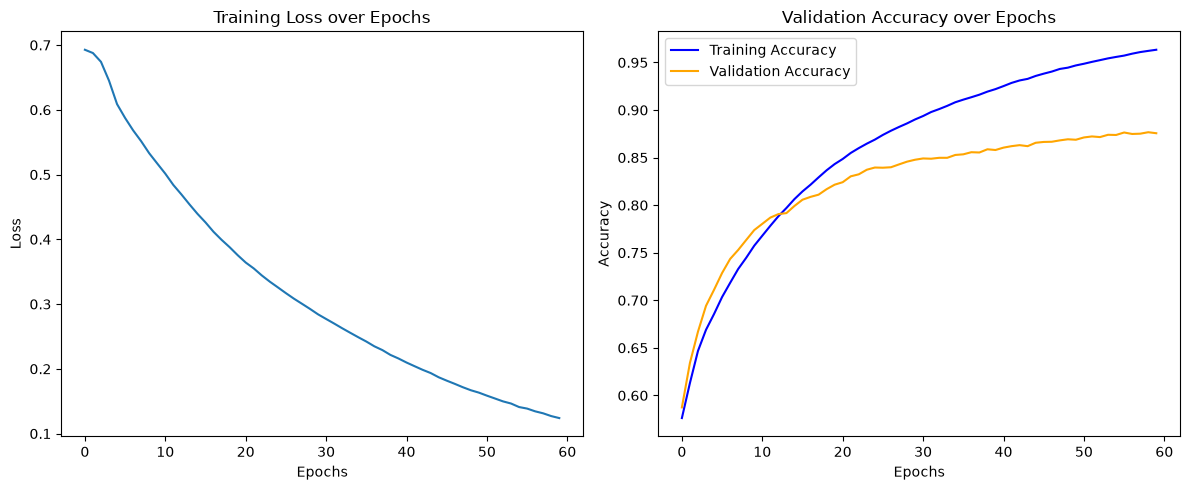

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history['loss'], label='Training Loss')
plt.title('Training Loss over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.subplot(1, 2, 2)
plt.plot(history['train_accuracy'], label='Training Accuracy', color='blue')
plt.plot(history['val_accuracy'], label='Validation Accuracy', color='orange')
plt.legend()
plt.title('Validation Accuracy over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.tight_layout()
# plt.savefig('training_result_1.png')
plt.show()

In [8]:
model.evaluate(X_val, y_val)

0.8756386637687683

In [9]:
example_input = torch.randint(0, 10, (1, X_train.shape[1]), dtype=torch.long)
model.save("adn_classifier_linear.pt", example_input)